In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [87]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

df = pd.read_csv(url)
df.sample(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
625,Male,18.000000,1.788459,51.552595,no,yes,2.897899,3.000000,Sometimes,no,1.835545,no,1.162519,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
510,Female,22.000000,1.675446,51.154201,yes,yes,3.000000,3.000000,Frequently,no,2.815293,no,1.978631,1.000000,no,Public_Transportation,Insufficient_Weight
1110,Male,24.657598,1.708800,83.520113,yes,yes,2.689577,2.714115,Sometimes,no,2.279214,no,0.970661,0.828549,Sometimes,Public_Transportation,Overweight_Level_II
279,Male,18.000000,1.790000,52.000000,no,no,3.000000,3.000000,Sometimes,no,2.000000,no,1.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
1171,Female,37.642177,1.676095,79.079738,yes,yes,2.802128,3.000000,Sometimes,no,1.744628,no,0.000000,0.721167,no,Automobile,Overweight_Level_II


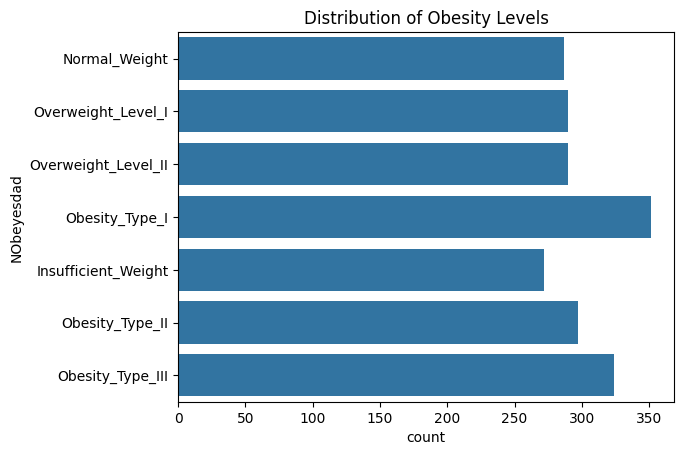

In [88]:
sns.countplot(y='NObeyesdad', data=df)
plt.title('Distribution of Obesity Levels')
plt.show()

In [89]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

None

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [90]:
continuous_columns = df.select_dtypes(include=['float64']).columns.tolist()

scaler = StandardScaler()
scaled_featurs = scaler.fit_transform(df[continuous_columns])

scaled_df = pd.DataFrame(scaled_featurs, columns=continuous_columns)

scaled_df = pd.concat([df.drop(columns=continuous_columns), scaled_df], axis=1)
scaled_df.sample(5)

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
914,Male,no,yes,no,no,no,Sometimes,Public_Transportation,Overweight_Level_I,-0.522124,-0.955390,-0.653910,-0.785019,-1.833248,1.618759,-0.012109,-1.080625
549,Female,yes,yes,Frequently,no,no,no,Public_Transportation,Insufficient_Weight,0.891777,-0.973539,-1.415699,-0.674232,1.567427,-0.013073,-0.221452,-1.080625
1357,Male,yes,yes,Sometimes,no,no,no,Public_Transportation,Obesity_Type_I,-0.994977,0.886816,0.833572,-0.785019,-0.270210,1.057074,-0.012109,-0.801578
1545,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_II,-0.026370,1.328356,1.308931,-0.029266,0.404153,0.787525,1.163820,0.081970
1666,Male,yes,yes,Sometimes,no,no,no,Public_Transportation,Obesity_Type_II,-0.240083,-0.641141,0.675349,0.844492,-1.435297,-0.774026,-0.990550,1.166912


In [91]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('NObeyesdad')

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = encoder.fit_transform(df[categorical_columns])

encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))
prepared_data = pd.concat([scaled_df.drop(columns=categorical_columns), encoded_df], axis=1)

prepared_data.sample(5)

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
535,Insufficient_Weight,-0.394266,0.117735,-1.336166,1.088342,0.604901,-1.230741,-0.547411,-0.659486,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
73,Normal_Weight,-0.837360,1.590034,-0.824368,-0.785019,0.404153,1.618759,1.163820,0.561997,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1099,Overweight_Level_II,-0.707799,-0.517206,-0.439016,0.650043,-0.310876,1.142145,-0.361550,0.278544,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1563,Obesity_Type_II,1.456507,-0.020200,0.658989,0.294878,-0.341930,-1.644905,1.143099,-1.080625,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2075,Obesity_Type_III,-0.470082,0.496444,2.318511,1.088342,0.404153,0.535792,0.477548,0.088468,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [92]:
prepared_data['NObeyesdad'] = prepared_data['NObeyesdad'].astype('category').cat.codes
prepared_data.sample(5)

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
1253,2,-0.206889,0.557859,0.760182,0.602454,0.404153,0.119113,-0.423408,0.182650,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2095,4,0.262388,-0.898991,0.701346,1.088342,0.404153,-0.475551,-1.186543,-0.183765,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
291,0,-1.152595,1.054029,-1.091697,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1781,3,1.483159,0.120361,0.637390,0.200152,-0.829263,-1.644905,0.776187,-1.041269,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
430,2,-0.994977,-0.553986,-0.060571,-0.785019,0.404153,-1.644905,-0.012109,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [93]:
X = prepared_data.drop(columns=['NObeyesdad'])
y = prepared_data['NObeyesdad']

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
model_ova = LogisticRegression(multi_class='ovr', max_iter=1000)
model_ova.fit(X_train, y_train)

LogisticRegression(max_iter=1000, multi_class='ovr')

In [96]:
y_ped_ova = model_ova.predict(X_test)

print("One-vs-All Logistic Regression Accuracy:", accuracy_score(y_test, y_ped_ova))

One-vs-All Logistic Regression Accuracy: 0.7446808510638298


In [97]:
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000))
model_ovo.fit(X_train, y_train)

OneVsOneClassifier(estimator=LogisticRegression(max_iter=1000))

In [98]:
y_pred_ovo = model_ovo.predict(X_test)

print("One-vs-One Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_ovo))

One-vs-One Logistic Regression Accuracy: 0.933806146572104


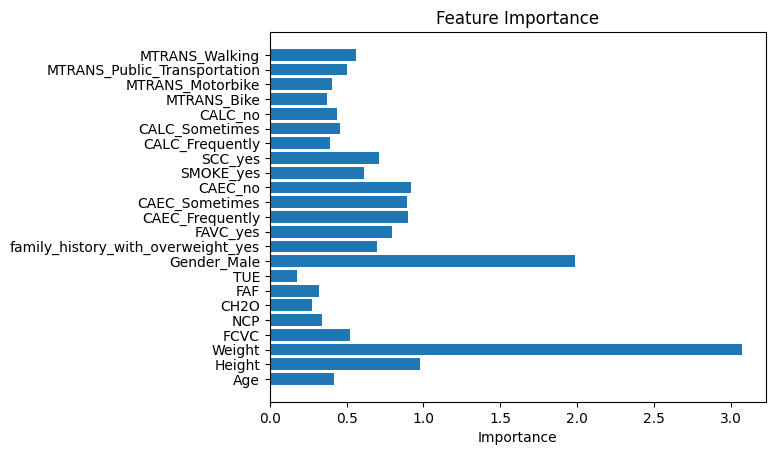

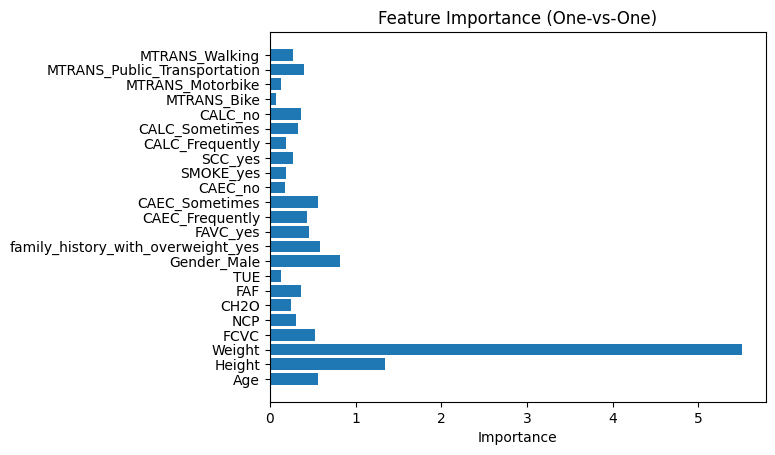

In [99]:
feature_importance = np.mean(np.abs(model_ova.coef_), axis=0)
plt.barh(X.columns, feature_importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

coefs = np.array([est.coef_[0] for est in model_ovo.estimators_])

feature_importance = np.mean(np.abs(coefs), axis=0)

plt.barh(X.columns, feature_importance)
plt.title("Feature Importance (One-vs-One)")
plt.xlabel("Importance")
plt.show()

In [ ]:
def obesity_risk_pipeline(data_path, test_size=0.2):
    data = pd.read_csv(data_path)

    continuous_columns = data.select_dtypes(include=['float64']).columns.tolist()
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(data[continuous_columns])
    
    scaled_df = pd.DataFrame(scaled_features, columns=scaler.get_feature_names_out(continuous_columns))
    
    scaled_data = pd.concat([data.drop(columns=continuous_columns), scaled_df], axis=1)

    categorical_columns = scaled_data.select_dtypes(include=['object']).columns.tolist()
    categorical_columns.remove('NObeyesdad')  # Exclude target column
    
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_features = encoder.fit_transform(scaled_data[categorical_columns])
    
    encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))
    
    prepped_data = pd.concat([scaled_data.drop(columns=categorical_columns), encoded_df], axis=1)
    
    prepped_data['NObeyesdad'] = prepped_data['NObeyesdad'].astype('category').cat.codes

    X = prepped_data.drop('NObeyesdad', axis=1)
    y = prepped_data['NObeyesdad']
   
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    
    model = LogisticRegression(multi_class='multinomial', max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))

obesity_risk_pipeline(url, test_size=0.2)

Accuracy: 0.8794326241134752
